In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss

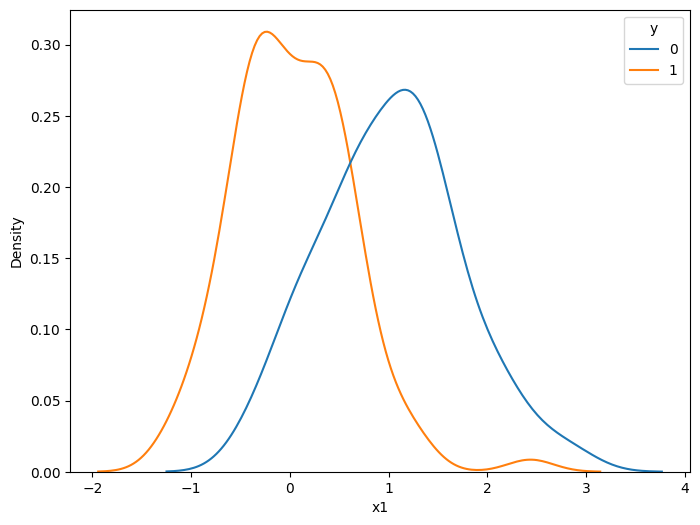

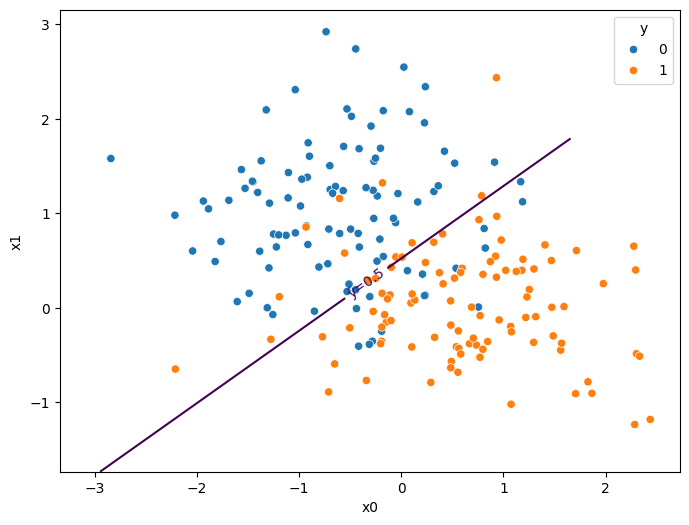

In [25]:
np.random.seed(42)
n = 100
mu0 = np.array([-0.5, 1.0])
mu1 = np.array([0.5, 0])
sigma0 = np.diag([0.8, 0.5])
sigma1 = np.diag([0.7, 0.4])

x0 = np.random.multivariate_normal(mu0, sigma0, size=n)
x1 = np.random.multivariate_normal(mu1, sigma1, size=n)

X = np.vstack([x0, x1])
y = np.hstack([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

df = pd.DataFrame(X, columns=['x0', 'x1'])
df['y'] = y

lr =LinearRegression().fit(X, y)
y_hat = lr.predict(X)
y_pred = (y_hat>=0.5).astype(int)

h = 0.05
x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max),
                     np.arange(y_min, y_max))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = lr.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x="x1", hue="y")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(df, x='x0', y='x1', hue='y')
cs = plt.contour(xx, yy, zz, levels=[0.5])
plt.clabel(cs, inline=True, fmt="ŷ=0.5")
plt.show()


<a list of 1 text.Text objects>

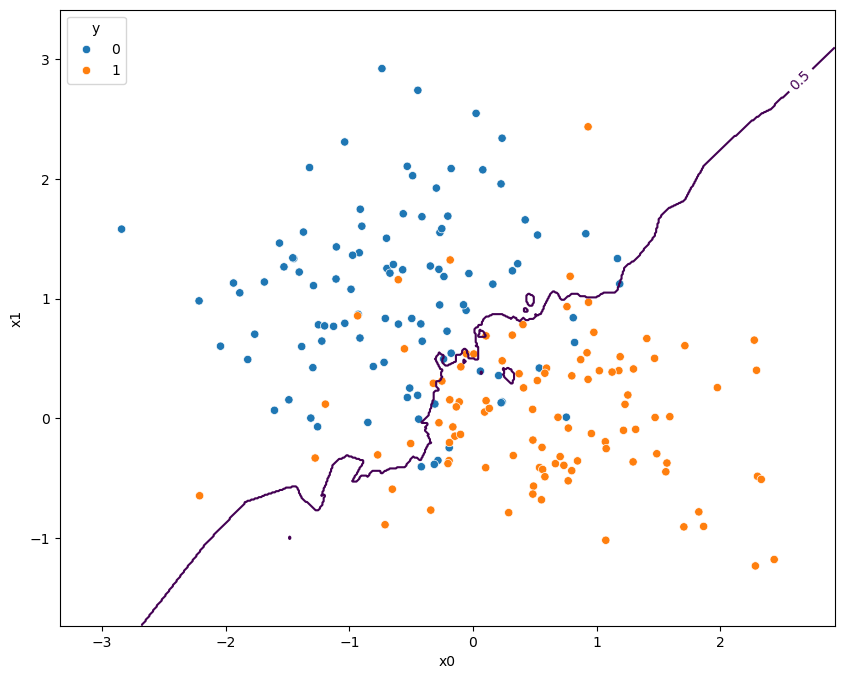

In [8]:
np.random.seed(42)
n = 100
mu0 = np.array([-0.5, 1.0])
mu1 = np.array([0.5, 0])
sigma0 = np.diag([0.8, 0.5])
sigma1 = np.diag([0.7, 0.4])

x0 = np.random.multivariate_normal(mu0, sigma0, size=n)
x1 = np.random.multivariate_normal(mu1, sigma1, size=n)

X = np.vstack([x0, x1])
y = np.hstack([np.zeros(n, dtype=int), np.ones(n, dtype=int)])

df = pd.DataFrame(X, columns=['x0', 'x1'])
df['y'] = y

knc = KNeighborsClassifier(n_neighbors=10)
knc.fit(X, y)
# y_pred = (y_hat>=0.5).astype(int)

x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = knc.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 8))
sns.scatterplot(df, x='x0', y='x1', hue='y')
cs = plt.contour(xx, yy, zz, levels=[0.5])
plt.clabel(cs, inline=True)



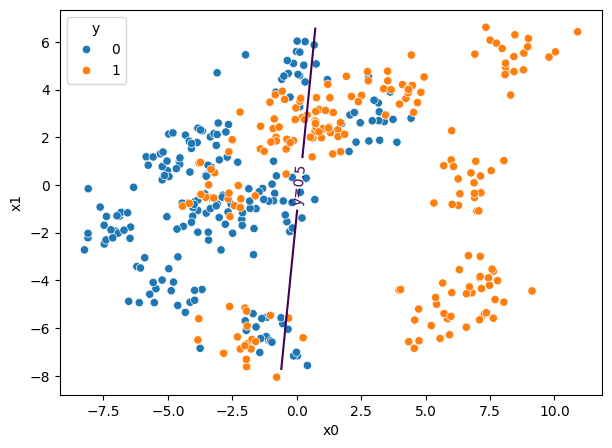

In [20]:
np.random.seed(42)

n_total_per_class = 200
n_components = 10
class_center0 = np.array([-2, 0.0])
class_center1 = np.array([ 2, 0.0])
mean_spread = 10      # 每個群之間的距離程度 
component_var = 0.6    # 每個群內部的散佈程度

pts_per = [n_total_per_class//n_components]*n_components # 混和權重
for i in range(n_total_per_class-sum(pts_per)):
    pts_per[i] += 1

comp_means0 = np.random.multivariate_normal(class_center0, mean_spread*np.eye(2), size=n_components)
chunks0 = []
for k in range(n_components):
    chunks0.append(np.random.multivariate_normal(comp_means0[k], component_var*np.eye(2), size=pts_per[k]))
x0 = np.vstack(chunks0)

comp_means1 = np.random.multivariate_normal(class_center1, mean_spread*np.eye(2), size=n_components)
chunks1 = []
for k in range(n_components):
    chunks1.append(np.random.multivariate_normal(comp_means1[k], component_var*np.eye(2), size=pts_per[k]))
x1 = np.vstack(chunks1)

X = np.vstack([x0, x1])
y = np.hstack([np.zeros(len(x0), dtype=int), np.ones(len(x1), dtype=int)])

lr = LinearRegression().fit(X, y)

x_min, x_max = X[:, 0].min()+0.3, X[:, 0].max()
y_min, y_max = X[:, 1].min()+0.3, X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = lr.predict(grid).reshape(xx.shape)

df = pd.DataFrame(X, columns=['x0', 'x1'])
df['y'] = y
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='x0', y='x1', hue='y')
cs = plt.contour(xx, yy, Z, levels=[0.5])
plt.clabel(cs, inline=True, fmt="ŷ=0.5")
plt.show()


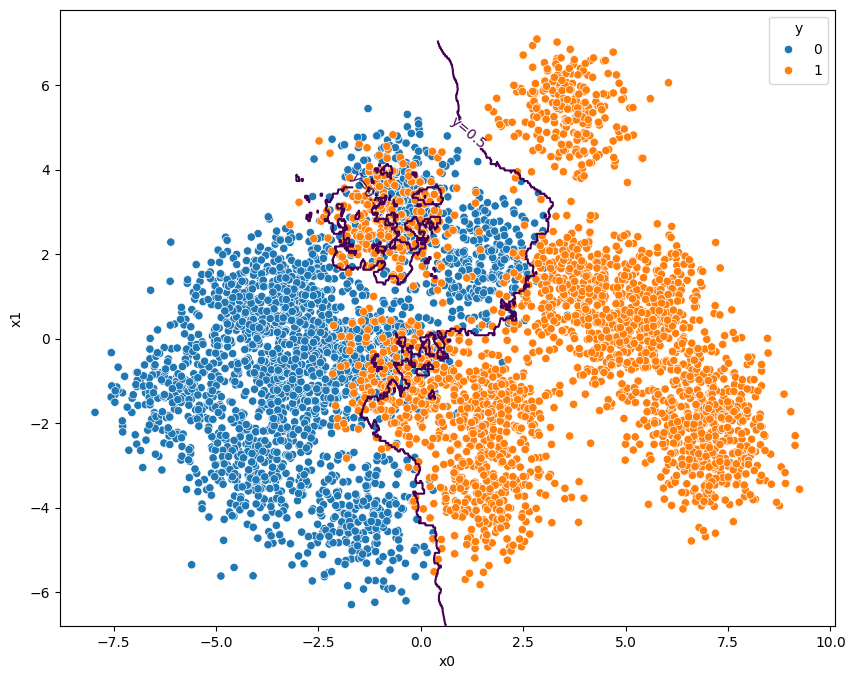

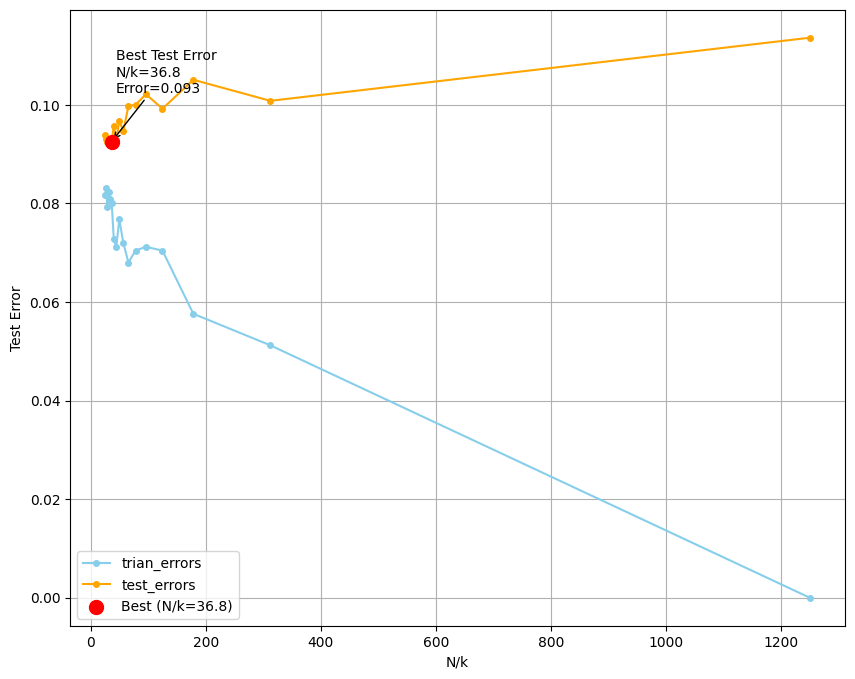

In [ ]:
np.random.seed(42)

n_total_per_class = 2500
n_components = 10
class_center0 = np.array([-2, 0.0])
class_center1 = np.array([ 2, 0.0])
mean_spread = 5      # 每個群之間的距離程度 
component_var = 0.6    # 每個群內部的散佈程度

pts_per = [n_total_per_class//n_components]*n_components # 混和權重
for i in range(n_total_per_class-sum(pts_per)):
    pts_per[i] += 1

comp_means0 = np.random.multivariate_normal(class_center0, mean_spread*np.eye(2), size=n_components)
chunks0 = []
for k in range(n_components):
    chunks0.append(np.random.multivariate_normal(comp_means0[k], component_var*np.eye(2), size=pts_per[k]))
x0 = np.vstack(chunks0)

comp_means1 = np.random.multivariate_normal(class_center1, mean_spread*np.eye(2), size=n_components)
chunks1 = []
for k in range(n_components):
    chunks1.append(np.random.multivariate_normal(comp_means1[k], component_var*np.eye(2), size=pts_per[k]))
x1 = np.vstack(chunks1)

X = np.vstack([x0, x1])
y = np.hstack([np.zeros(len(x0), dtype=int), np.ones(len(x1), dtype=int)])

knc = KNeighborsClassifier(n_neighbors=10)
knc.fit(X, y)

x_min, x_max = X[:, 0].min()+0.3, X[:, 0].max()
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.05))
Z = knc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

df = pd.DataFrame(X, columns=['x0', 'x1'])
df['y'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(df, x='x0', y='x1', hue='y')
cs = plt.contour(xx, yy, Z, levels=[0.5])
plt.clabel(cs, inline=True, fmt="ŷ=0.5")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.75, random_state=42)

N = len(X_train)
train_errors = []
test_errors = []
effective = []
for k in range(1, 51, 3):
    knc = KNeighborsClassifier(n_neighbors=k)
    knc.fit(X_train, y_train)
    y_pred_train = knc.predict(X_train)
    y_pred_test = knc.predict(X_test)

    err_train = zero_one_loss(y_train, y_pred_train)
    err_test = zero_one_loss(y_test, y_pred_test)

    train_errors.append(err_train)
    test_errors.append(err_test)

    effective.append(N/k)

best_effect = effective[np.argmin(test_errors)]
best_test_error = test_errors[np.argmin(test_errors)]

plt.figure(figsize=(10, 8))
plt.plot(effective, train_errors, marker='o', markersize=4, color='skyblue', label='trian_errors')
plt.plot(effective, test_errors, marker='o', markersize=4, color='orange', label='test_errors')
plt.scatter(best_effect, best_test_error, color="red", s=100, zorder=5, label=f"Best (N/k={best_effect:.1f})")
plt.annotate(f"Best Test Error\nN/k={best_effect:.1f}\nError={best_test_error:.3f}",
             xy=(best_effect, best_test_error),
             xytext=(best_effect*1.2, best_test_error+0.01),
             arrowprops=dict(facecolor='red', arrowstyle="->"))
plt.xlabel("N/k")
plt.ylabel("Test Error")
plt.grid(True)
plt.legend()
plt.show()